### ***Mini-Project - SMS Spam Classifier***

In [2]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import the data 
data = pd.read_csv('spam.csv', encoding='latin-1')

print(data.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [4]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB
None


## Stages of this Mini Project
### (i) Data Cleaning
### (ii) EDA
### (iii) Text Preprocessing
### (iv) Model Building
### (v) Model Evaluation
### (vi) Improvements if needed
### (vii) Convert to website and deploy 

### ***Step 1. Data Cleaning***

In [5]:
# Remove Unnecessary columns
data = data.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'] , axis=1)

print("="*50)
print(f"\t\t\tRaw DataSet")
print("="*50)

print(data.head())

			Raw DataSet
     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [6]:
# Change the columns names
data.rename(columns={'v1':'Target','v2':'Text'} , inplace=True)

data.head(5)

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# Let us encode ham = 0 and spam = 1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

data['Target'] = encoder.fit_transform(data['Target'])

print(data.head())

   Target                                               Text
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...


In [8]:
# Check the missing values in our data
print(data.isnull().sum())

Target    0
Text      0
dtype: int64


- No nulls in the data -> Perfect

In [9]:
# Let us check if duplicate values are there or not in our data
print(data.duplicated().sum())

403


- There are 403 duplicate data, so we must remove them

In [11]:
# Removing duplicate rows
print(f"Before Removal: {data.shape}\n")

data.drop_duplicates(keep = 'first' , inplace=True)

print(f"After Removal: {data.shape}\n")


Before Removal: (5572, 2)

After Removal: (5169, 2)



### ***Step 2. EDA***

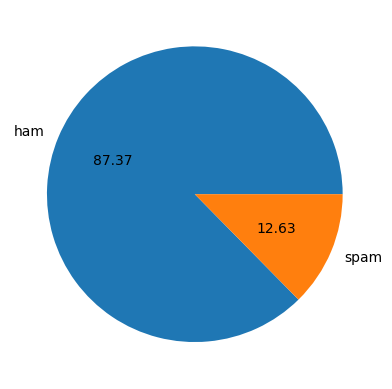

In [12]:
# Distribution of Spam in our data
plt.pie(data['Target'].value_counts() , labels=['ham','spam'] , autopct="%.2f")
plt.show()


- **Data is imbalanced**

**We will create three new columns for EDA:**
- Number of characters in a SMS
- Number of words in a SMS
- Number of sentences in a SMS 

In [13]:
# import nltk
# %pip install nltk
import nltk # natural language toolkit

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Pradhuman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
# Characters count

data['text_length'] = data['Text'].apply(len)

# Number of Words used

data['word_count'] = data['Text'].apply(lambda x : len(nltk.word_tokenize(x)))

# Number of sentences in a SMS

data['sentence_count'] = data['Text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [15]:
print(data.head())

   Target                                               Text  text_length  \
0       0  Go until jurong point, crazy.. Available only ...          111   
1       0                      Ok lar... Joking wif u oni...           29   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...          155   
3       0  U dun say so early hor... U c already then say...           49   
4       0  Nah I don't think he goes to usf, he lives aro...           61   

   word_count  sentence_count  
0          24               2  
1           8               2  
2          37               2  
3          13               1  
4          15               1  


In [22]:
data[['text_length','word_count','sentence_count']].describe()

,text_length,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


- One SMS where 910 characters were used. Obviously it has the most words and sentences used too.
- Average characters in a SMS is around 79, Word count is around 18 and sentences is around 2

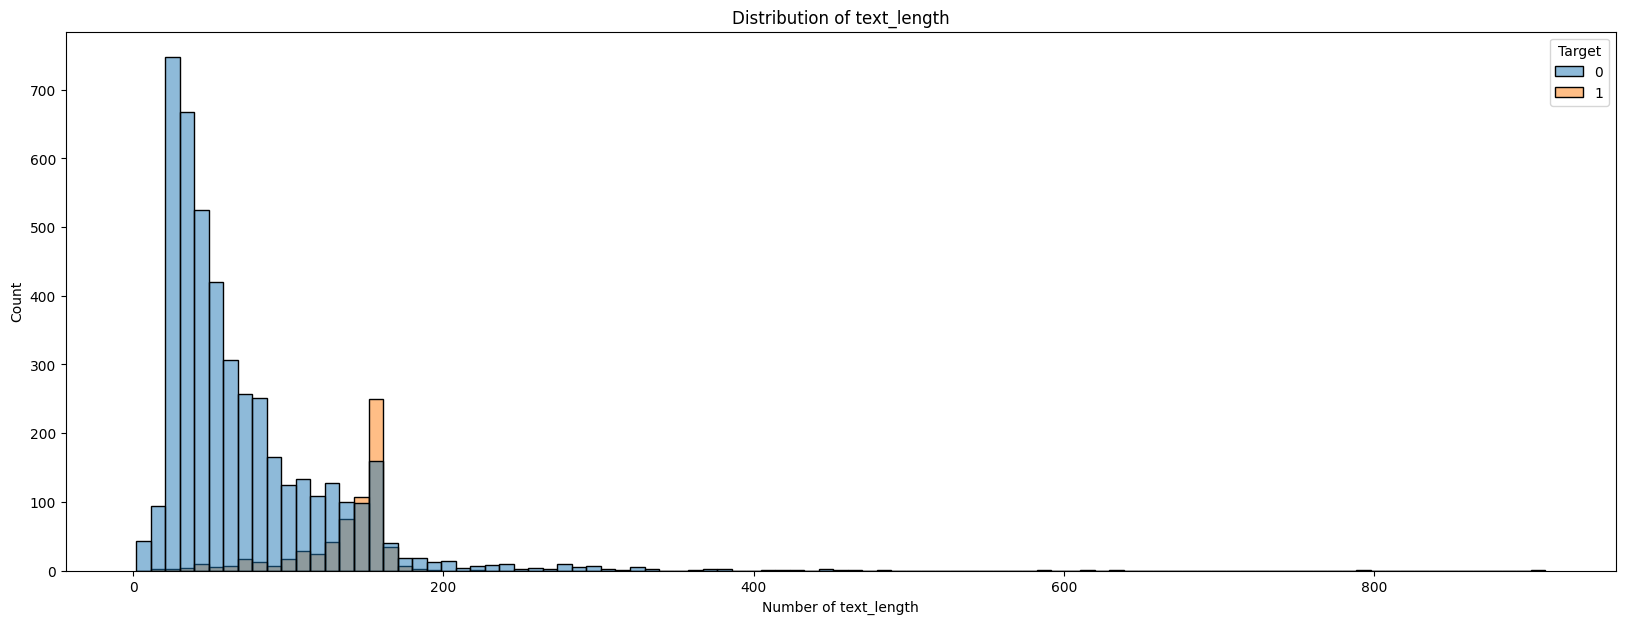

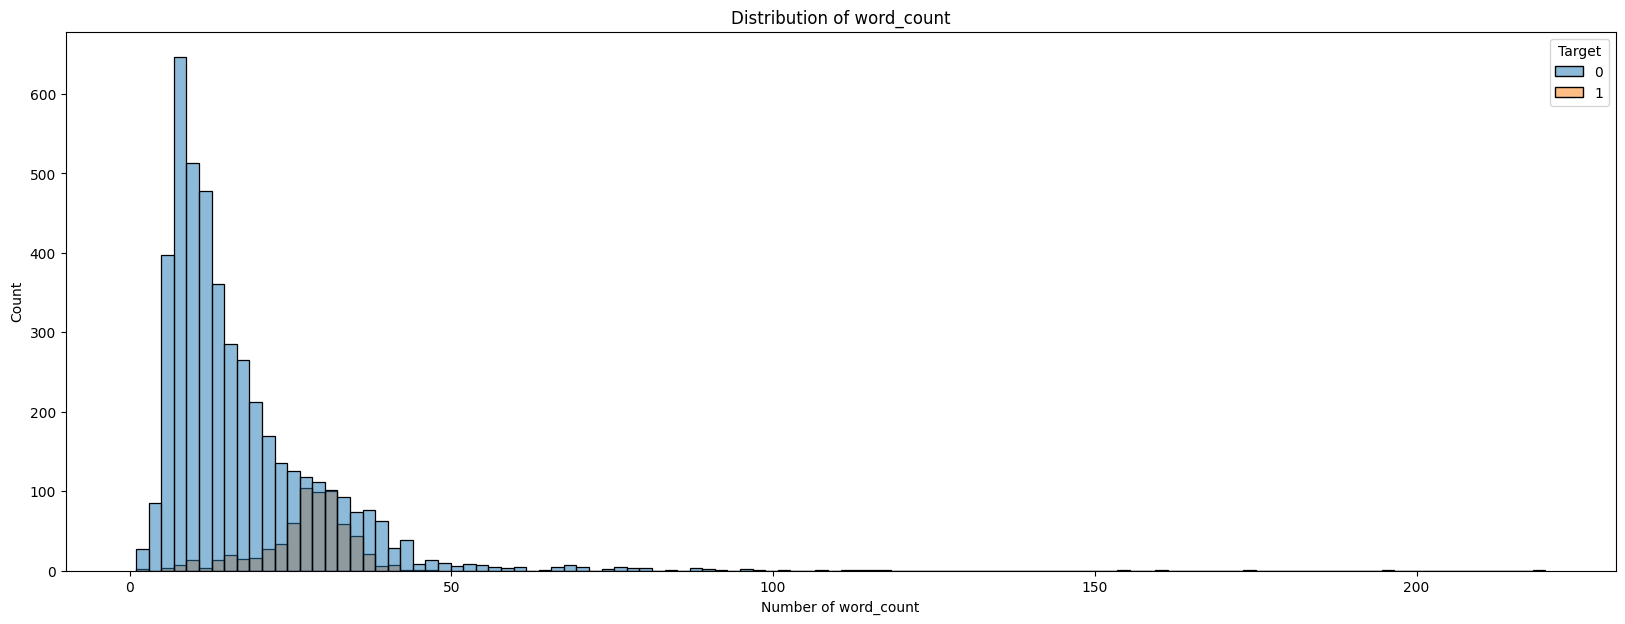

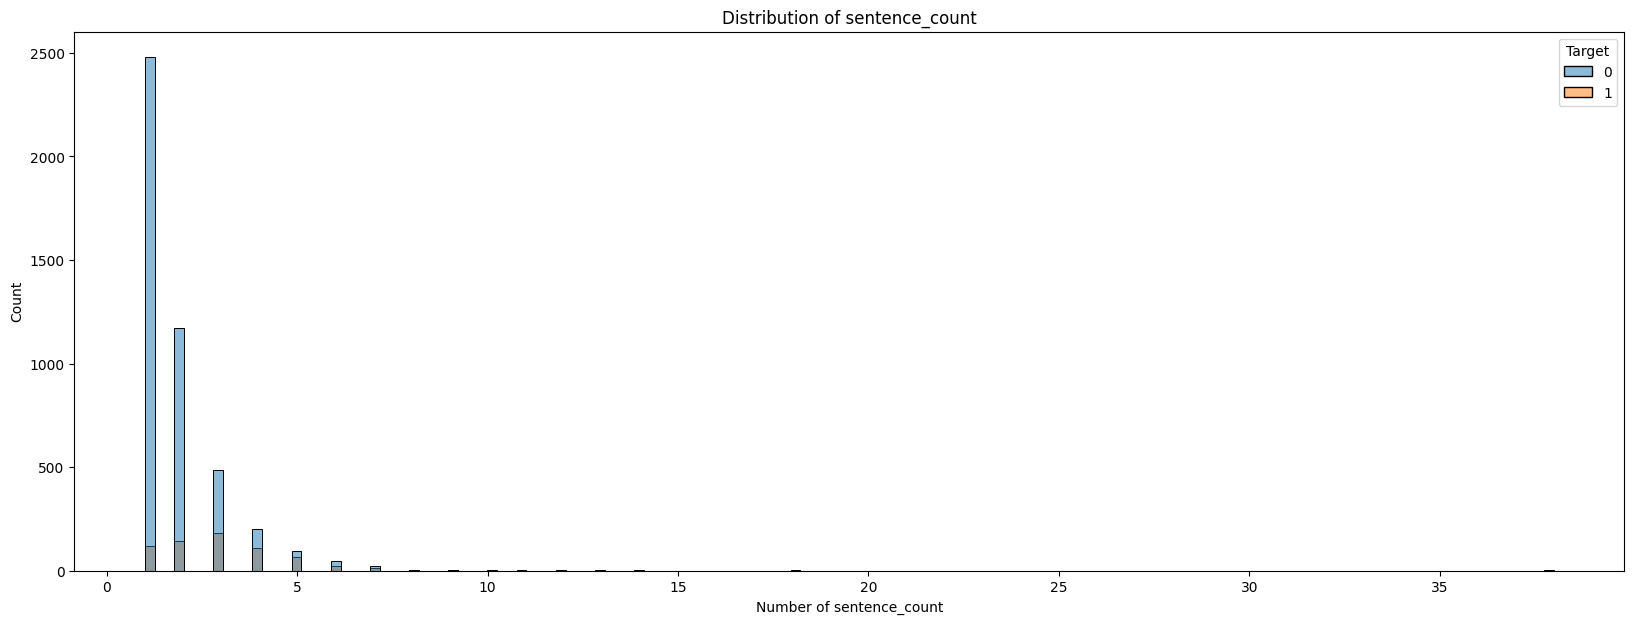

In [30]:
# Checking the distribution of These new features
features = ['text_length','word_count','sentence_count']
for feat in features:
    plt.figure(figsize=(20,7))
    sns.histplot(x = data[feat] , edgecolor='k' , hue=data['Target'])
    plt.title(f'Distribution of {feat}')
    plt.xlabel(f'Number of {feat}')
    plt.show()

**All the three features are highly right skewed**
- Most of the SMS are very small, but some are very big
- Spam messages are generally made of more words and characters, but outliers exist

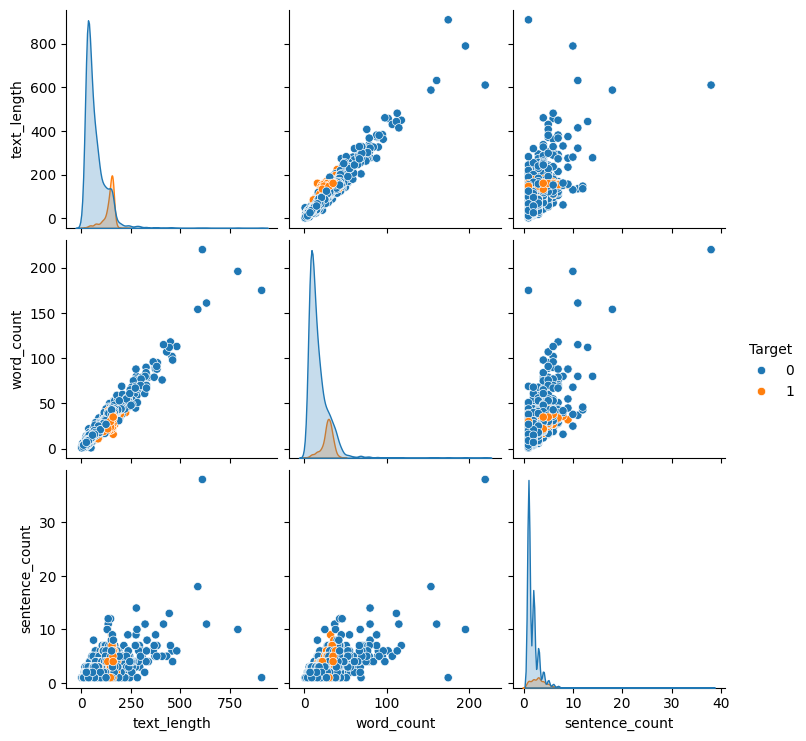

In [34]:
# Correlation b/w the features of the data 
sns.pairplot(data , hue='Target')
plt.show()

- Character count, word count and sentences count are correlated -> Very obvious 
- We do not see any outliers in spam category

<Axes: >

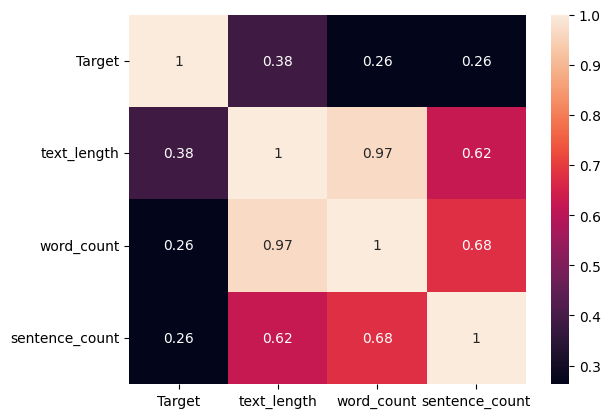

In [38]:
# Checking the pearson correlation

sns.heatmap(data.drop('Text',axis=1).corr() , annot =True)

- Word count and text length have a correlation of 0.97 Very High
- Others are okay only

### What we can do is- We will keep only one column - text_length

### ***Step 3. Text/ Data Preprocessing***

- Lower case
- Tokenization
- Remove Stop words
- Remove punctuation marks
- Stemming or lemmatization

In [ ]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
def transform_text(text):
    # lower case
    text = text.lower()
    
    # tokenization
    text = nltk.word_tokenize(text)

    # Remove extra characters other than alphanumeric
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    #removing stopwords and punctuation marks
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    # Stemming or Lemmatization
    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i))
    
    text = y[:]
    return text






In [42]:
data['Text'][560]

"Hi msg me:)i'm in office.."

In [67]:
transform_text("Hi msg me:)i'm in ?office and I love singing and cheering isn't it amazing..")

['hi', 'msg', 'offic', 'love', 'sing', 'cheer', 'amaz']